# Football Player Injury Prediction

This notebook presents an end-to-end, reproducible machine learning workflow to predict whether a player will be injured next season (`Injury_Next_Season`).

<a id='toc'></a>
## Table of Contents:

### [1. Setup](#1-setup-and-data-loading)
   - [1.1 Libraries import](#11-libraries-import)


<a id='1-setup-and-data-loading'></a>
## 1. Setup and Data Loading

### 1.1 Libraries and Configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_STATE = 42
TARGET = "Injury_Next_Season"

### 1.2 Load Dataset

In [104]:
df = pd.read_csv("data.csv")

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset shape: 800 rows x 19 columns


,Age,Height_cm,Weight_kg,Position,Training_Hours_Per_Week,Matches_Played_Past_Season,Previous_Injury_Count,Knee_Strength_Score,Hamstring_Flexibility,Reaction_Time_ms,Balance_Test_Score,Sprint_Speed_10m_s,Agility_Score,Sleep_Hours_Per_Night,Stress_Level_Score,Nutrition_Quality_Score,Warmup_Routine_Adherence,Injury_Next_Season,BMI
0,22,173,64,Midfielder,11.575308,36,1,77.460279,79.115738,284.487853,91.212476,5.874630,77.599705,8.238293,46.616415,81.472206,1,0,21.383942
1,18,170,67,Midfielder,12.275869,37,2,72.634442,82.541688,250.579249,87.294078,5.796269,94.418987,8.983737,49.368037,81.056677,1,0,23.183391
2,22,186,75,Forward,12.254896,12,2,77.064490,75.943631,269.119918,83.440688,5.731209,70.179176,7.229193,43.132808,64.877457,0,1,21.678807
3,20,172,62,Defender,9.006678,11,1,82.810232,73.878324,226.376412,87.591894,6.220212,83.473824,7.681029,51.528529,89.824744,1,0,20.957274
4,18,172,94,Midfielder,12.683668,10,2,76.772859,76.653043,229.021042,83.125161,5.385958,87.037256,6.728091,52.379718,71.569197,0,1,31.773932


<a id='2-exploratory-data-analysis'></a>
## 2. Exploratory Data Analysis

In [105]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nTarget distribution:")
display(df[TARGET].value_counts().rename_axis(TARGET).to_frame("count"))

Column names:
['Age', 'Height_cm', 'Weight_kg', 'Position', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'Injury_Next_Season', 'BMI']

Data types:


,dtype
Age,int64
Height_cm,int64
Weight_kg,int64
Position,str
Training_Hours_Per_Week,float64
Matches_Played_Past_Season,int64
Previous_Injury_Count,int64
Knee_Strength_Score,float64
Hamstring_Flexibility,float64
Reaction_Time_ms,float64



Target distribution:


,count
Injury_Next_Season,
0,400
1,400


In [106]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,800.0,21.135000,1.991037,18.000000,19.000000,21.000000,23.000000,24.000000
Height_cm,800.0,177.407500,7.148974,154.000000,173.000000,177.000000,182.000000,200.000000
Weight_kg,800.0,73.235000,9.929276,45.000000,66.000000,73.000000,80.000000,105.000000
Training_Hours_Per_Week,800.0,9.951150,2.610395,5.000000,8.127151,9.895710,11.535140,18.866608
Matches_Played_Past_Season,800.0,22.332500,10.311516,5.000000,13.000000,22.000000,32.000000,39.000000
Previous_Injury_Count,800.0,1.536250,1.292584,0.000000,1.000000,1.000000,2.000000,8.000000
Knee_Strength_Score,800.0,74.933249,6.672704,52.391351,70.432656,74.997933,79.632391,93.900051
Hamstring_Flexibility,800.0,79.154123,6.782332,58.180381,74.495959,79.187909,83.813179,100.000000
Reaction_Time_ms,800.0,249.423244,22.532387,180.000000,234.089585,249.127328,265.105082,306.730851
Balance_Test_Score,800.0,83.832337,6.931657,60.059484,79.044910,84.156236,88.877902,100.000000


In [107]:
quality_summary = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(),
    }
).sort_values(["missing_count", "n_unique"], ascending=[False, True])

print(f"Duplicate rows: {df.duplicated().sum()}")
display(quality_summary)

Duplicate rows: 0


,missing_count,missing_pct,n_unique
Warmup_Routine_Adherence,0,0.0,2
Injury_Next_Season,0,0.0,2
Position,0,0.0,4
Age,0,0.0,7
Previous_Injury_Count,0,0.0,9
Matches_Played_Past_Season,0,0.0,35
Height_cm,0,0.0,42
Weight_kg,0,0.0,53
BMI,0,0.0,538
Training_Hours_Per_Week,0,0.0,781


<Figure size 1000x500 with 0 Axes>

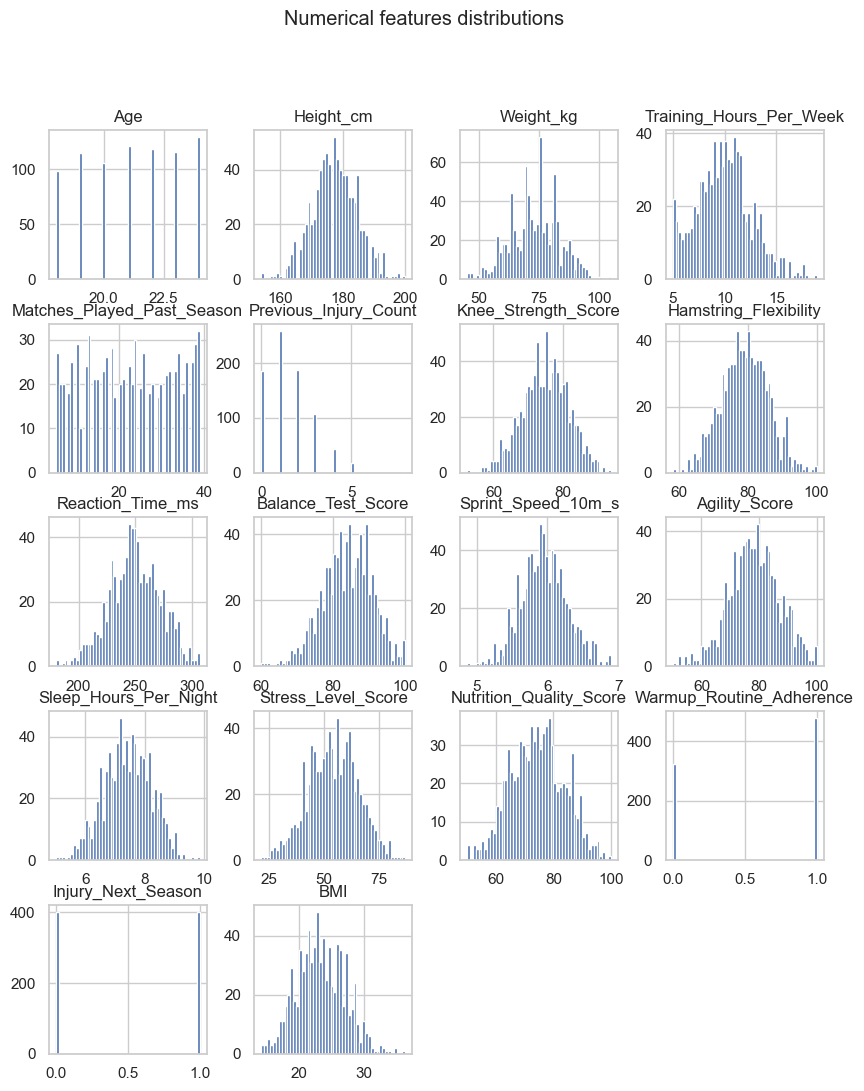

In [108]:
plt.figure()
df.hist(bins=50, figsize=(10,12))
plt.suptitle('Numerical features distributions')
plt.show()

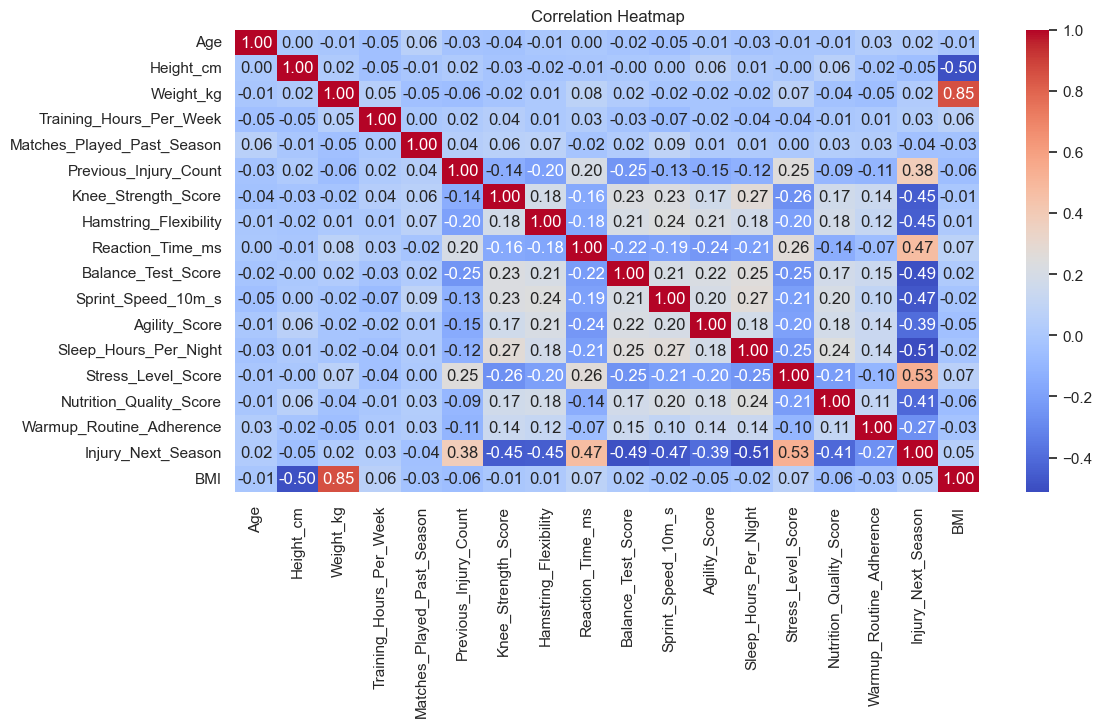

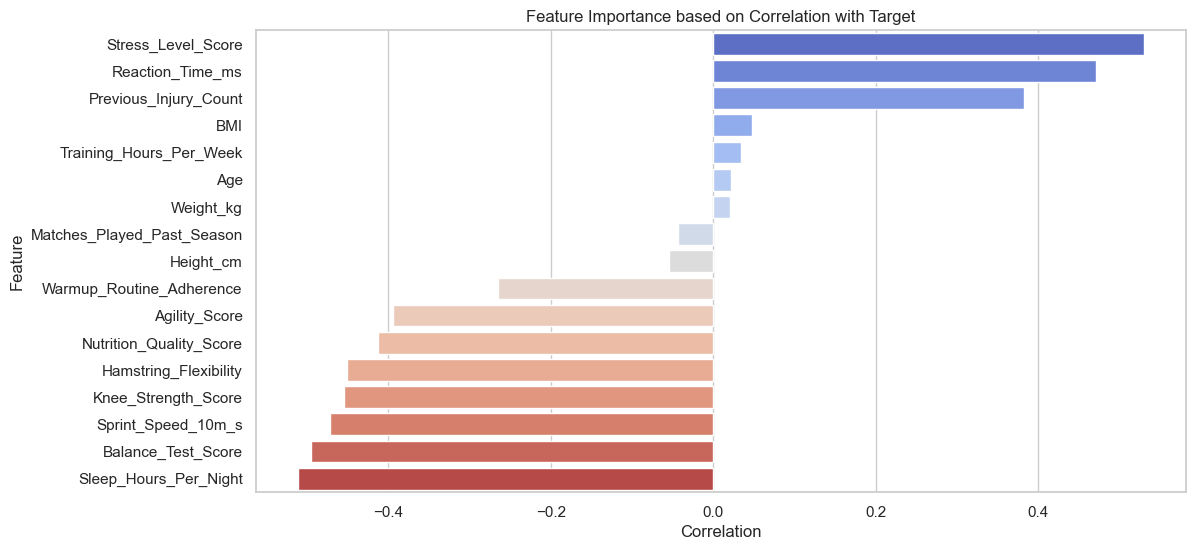

In [109]:
numeric_features = df.select_dtypes(include = np.number).corr()

plt.figure(figsize = (12,6))
sns.heatmap(numeric_features, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

imp = numeric_features[TARGET].sort_values(ascending = False).drop(TARGET)
imp_df = imp.reset_index()
imp_df.columns = ["Feature", "Correlation"]

plt.figure(figsize=(12,6))
sns.barplot(x="Correlation", y="Feature", data=imp_df, palette="coolwarm")
plt.title("Feature Importance based on Correlation with Target")
plt.show()

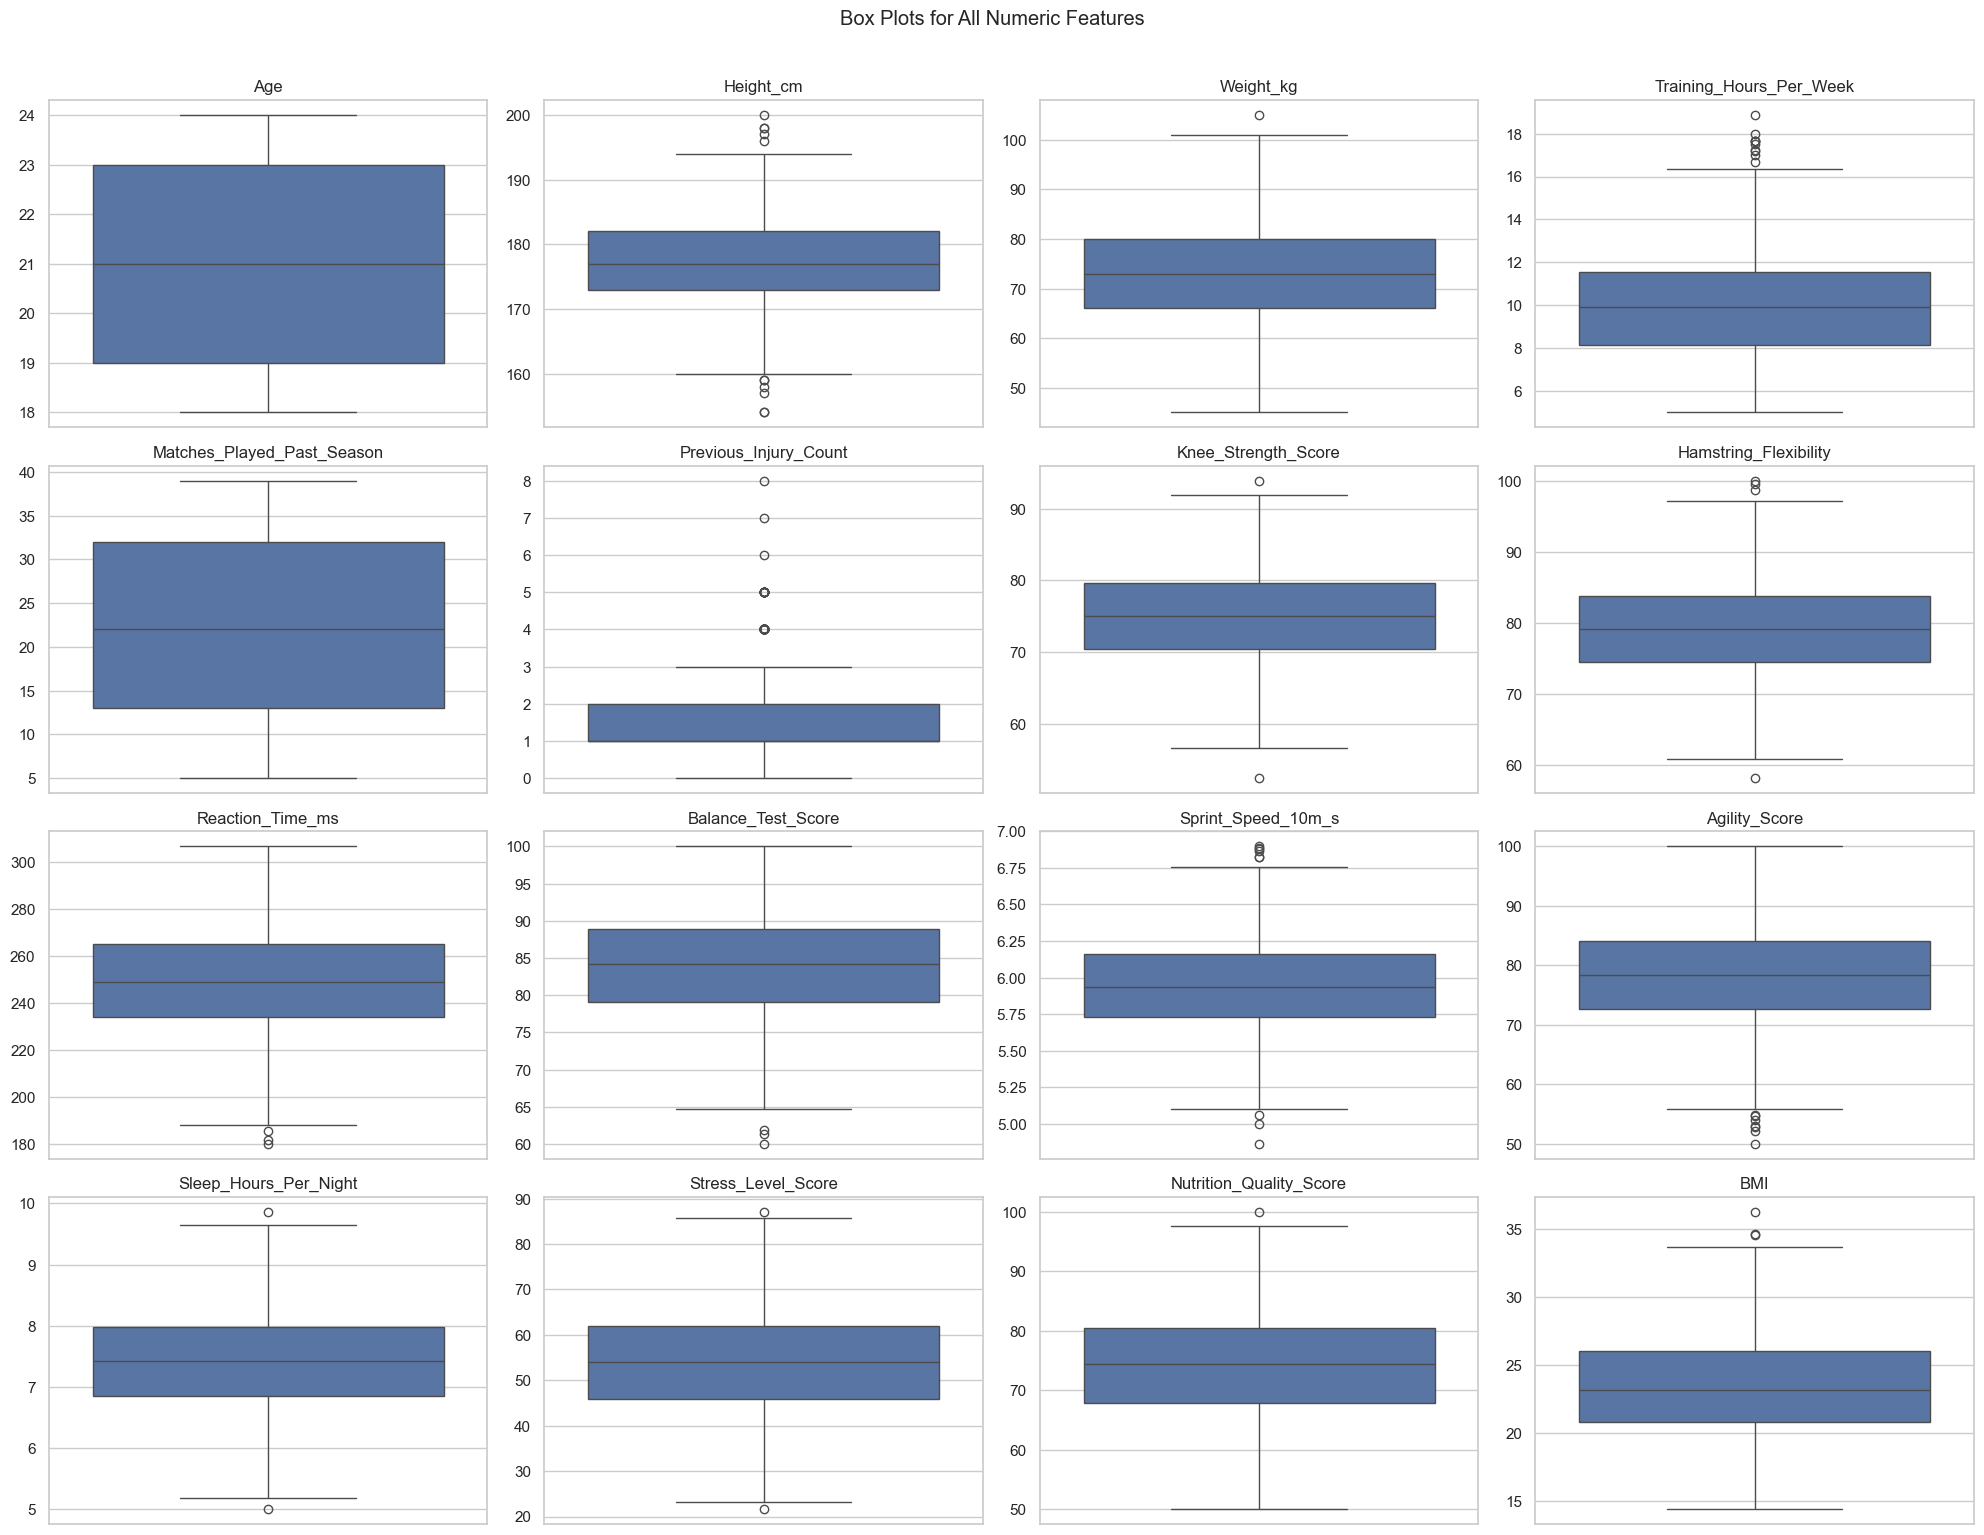

In [110]:
numeric_cols = [c for c in numeric_features if c != TARGET and c != 'Warmup_Routine_Adherence']

n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3.8 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(len(numeric_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Box Plots for All Numeric Features", y=1.01)
plt.tight_layout()
plt.show()

,injury_rate,players
Position,,
Forward,54.31%,197
Midfielder,50.23%,213
Defender,48.53%,204
Goalkeeper,46.77%,186


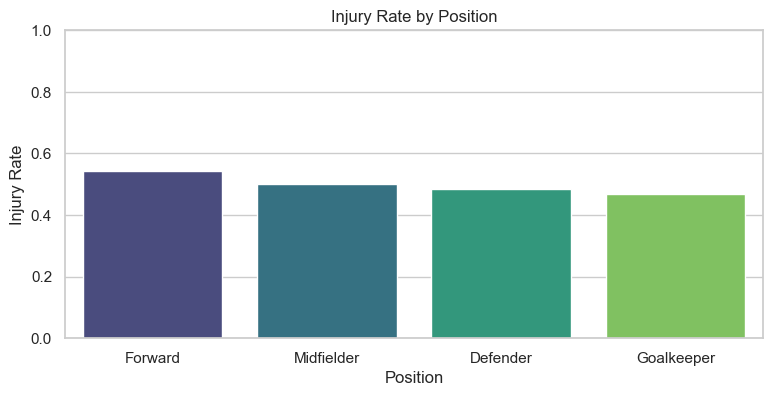

In [111]:
position_risk = (
    df.groupby("Position")[TARGET]
    .agg(["mean", "count"])
    .rename(columns={"mean": "injury_rate", "count": "players"})
    .sort_values("injury_rate", ascending=False)
)

display(position_risk.style.format({"injury_rate": "{:.2%}"}))

plt.figure(figsize=(9, 4))
sns.barplot(
    data=position_risk.reset_index(),
    x="Position",
    y="injury_rate",
    hue="Position",
    palette="viridis",
    legend=False,
    order=position_risk.index.tolist(),
)
plt.title("Injury Rate by Position")
plt.ylabel("Injury Rate")
plt.ylim(0, 1)
plt.show()

In [112]:
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_position = ohe.fit_transform(df[["Position"]])
encoded_position_to_df = pd.DataFrame(
    encoded_position,
    columns=ohe.get_feature_names_out(["Position"]),
    index=df.index,
 )
df_final = pd.concat([df.drop(columns=["Position"]), encoded_position_to_df], axis=1)

print(df_final.shape)
print(df_final.columns.tolist())

(800, 21)
['Age', 'Height_cm', 'Weight_kg', 'Training_Hours_Per_Week', 'Matches_Played_Past_Season', 'Previous_Injury_Count', 'Knee_Strength_Score', 'Hamstring_Flexibility', 'Reaction_Time_ms', 'Balance_Test_Score', 'Sprint_Speed_10m_s', 'Agility_Score', 'Sleep_Hours_Per_Night', 'Stress_Level_Score', 'Nutrition_Quality_Score', 'Warmup_Routine_Adherence', 'Injury_Next_Season', 'BMI', 'Position_Forward', 'Position_Goalkeeper', 'Position_Midfielder']


In [113]:
data_for_model = df_final.copy()

X = data_for_model.drop(columns=[TARGET])
y = data_for_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (640, 20) | Test shape: (160, 20)


In [ ]:
models = [
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    RandomForestClassifier(random_state=RANDOM_STATE),
    KNeighborsClassifier(),
]

for i in models:
    i.fit(X_train, y_train)
    print(f"{i.__class__.__name__} successfully trained")

    r2 = accuracy_score(y_test, i.predict(X_test))
    print(f"accuracy_score for {i.__class__.__name__}: {r2:.4f}")
    print("-" * 40)

LogisticRegression successfully trained
accuracy_score for LogisticRegression: 0.9375
----------------------------------------
DecisionTreeClassifier successfully trained
accuracy_score for DecisionTreeClassifier: 0.8000
----------------------------------------
RandomForestClassifier successfully trained
accuracy_score for RandomForestClassifier: 0.9250
----------------------------------------
KNeighborsClassifier successfully trained
accuracy_score for KNeighborsClassifier: 0.8875
----------------------------------------


In [ ]:
model_scores = {}

for m in models:
    model_scores[m.__class__.__name__] = accuracy_score(y_test, m.predict(X_test))

best_model_name = max(model_scores, key=model_scores.get)
best_model = next(m for m in models if m.__class__.__name__ == best_model_name)

print(f"Best model: {best_model_name}")
print(f"Best accuracy: {model_scores[best_model_name]:.4f}")
display(pd.DataFrame(model_scores.items(), columns=["Model", "Accuracy"]).sort_values("Accuracy", ascending=False))

Best model: LogisticRegression
Best accuracy: 0.9375


,Model,Accuracy
0,LogisticRegression,0.9375
2,RandomForestClassifier,0.9250
3,KNeighborsClassifier,0.8875
1,DecisionTreeClassifier,0.8000


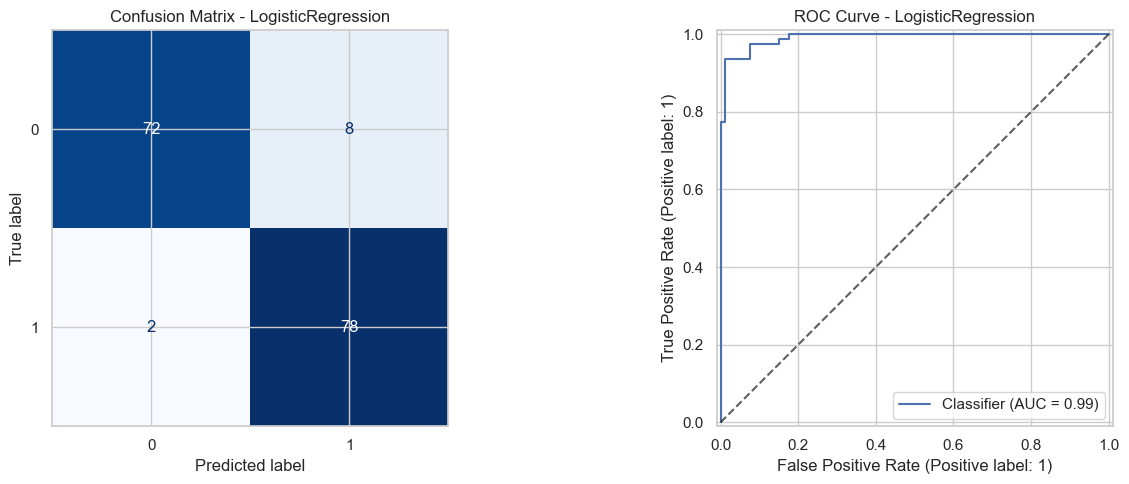

In [ ]:
y_pred_best = best_model.predict(X_test)
y_score_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,    
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
 )
axes[0].set_title(f"Confusion Matrix - {best_model_name}")

RocCurveDisplay.from_predictions(y_test, y_score_best, ax=axes[1])
axes[1].set_title(f"ROC Curve - {best_model_name}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.7)

plt.tight_layout()
plt.show()